In [86]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from skimage.util import random_noise, img_as_float64
from skimage.restoration import denoise_tv_chambolle

from scipy.ndimage import gaussian_filter, median_filter

In [87]:
def load_image(image_path):
    image = Image.open(image_path).convert('L')
    image_array = np.array(image) 
    image_float = img_as_float64(image_array)
    return image_float

def add_gaussian_noise(image, std_dev):
    noisy_image = random_noise(image, mode='gaussian', clip=True, var=std_dev**2)
    return noisy_image

def plot_orginal_and_noisy(original_image, noisy_image):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(noisy_image, cmap='gray')
    plt.title('Sa šumom')
    plt.axis('off')

def denoise_gaussian_filter(image, std_dev):
    return gaussian_filter(image, sigma=std_dev)

def denoise_median_filter(image, size):
    return median_filter(image, size=size)

def denoise_tv(noisy_image, weight):
    return denoise_tv_chambolle(noisy_image, weight=weight, channel_axis=None)

In [101]:
def compare(noisy_image, gaussian_denoised, median_denoised, tv_denoised):
    
    plt.figure(figsize=(12, 12))
    
    plt.subplot(2, 2, 1)
    plt.imshow(noisy_image, cmap='gray')
    plt.title('Sa šumom')
    plt.axis('off')
    
    plt.subplot(2, 2, 2)
    plt.imshow(gaussian_denoised, cmap='gray')
    plt.title('Gausov filter')
    plt.axis('off')
    
    plt.subplot(2, 2, 3)
    plt.imshow(median_denoised, cmap='gray')
    plt.title('Median filter')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(tv_denoised, cmap='gray')
    plt.title('TV denoising')
    plt.axis('off')
    
    plt.show()

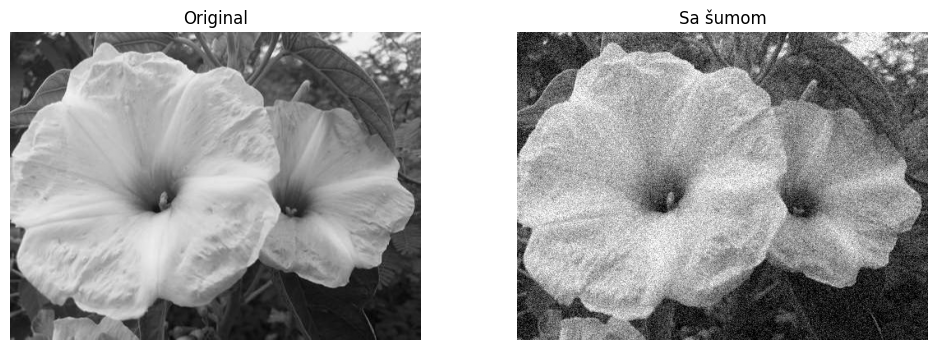

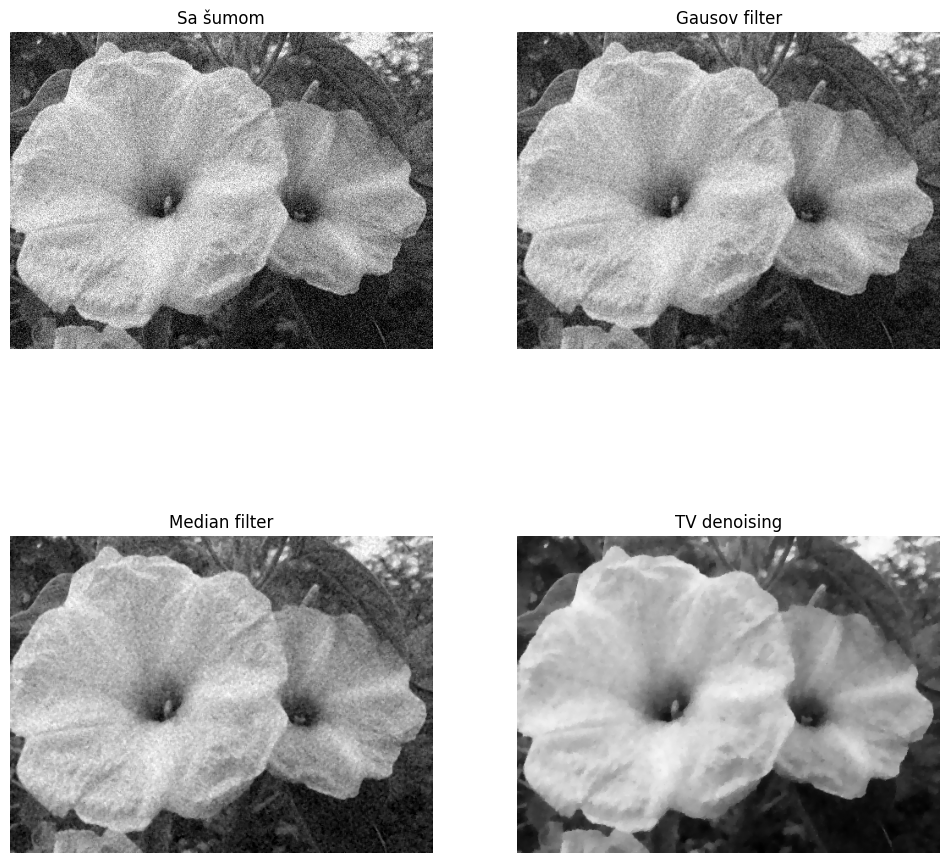

In [106]:
original_image = load_image('flowers.jpg')

noisy_image = add_gaussian_noise(original_image, 0.1)

gaussian_denoised = denoise_gaussian_filter(noisy_image, 0.5)

median_denoised = denoise_median_filter(noisy_image, 3)

tv_denoised = denoise_tv(noisy_image, 0.1)

plot_orginal_and_noisy(original_image, noisy_image)
compare(noisy_image, gaussian_denoised, median_denoised, tv_denoised)